# Forecasting using RNN networks

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
data.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


## ARIMA model - baseline 

In [4]:
# !pip install --upgrade numpy==1.26.4

ADF Test Statistic: -30.94015531837786
p-value: 0.0
Data is stationary.


/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_

Optimal ARIMA order: (4, 0, 0)


/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             close_diff   No. Observations:                47073
Model:                 ARIMA(4, 0, 0)   Log Likelihood             -318389.838
Date:                Sat, 01 Feb 2025   AIC                         636791.676
Time:                        16:21:37   BIC                         636844.232
Sample:                    05-15-2018   HQIC                        636808.185
                         - 09-27-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3725      0.937      0.397      0.691      -1.465       2.210
ar.L1         -0.0073      0.002     -4.339      0.000      -0.011      -0.004
ar.L2         -0.0185      0.002     -9.560      0.0

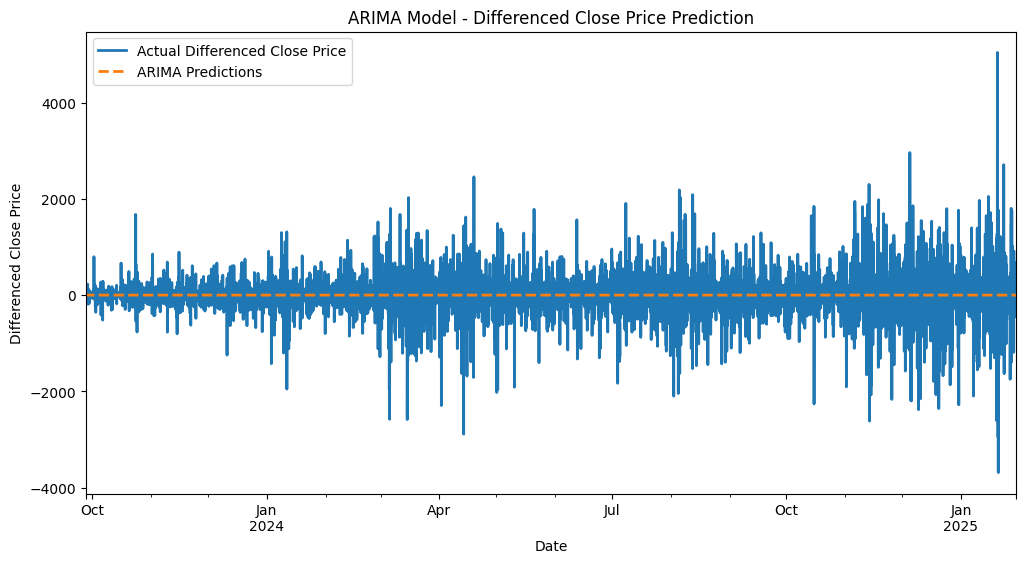

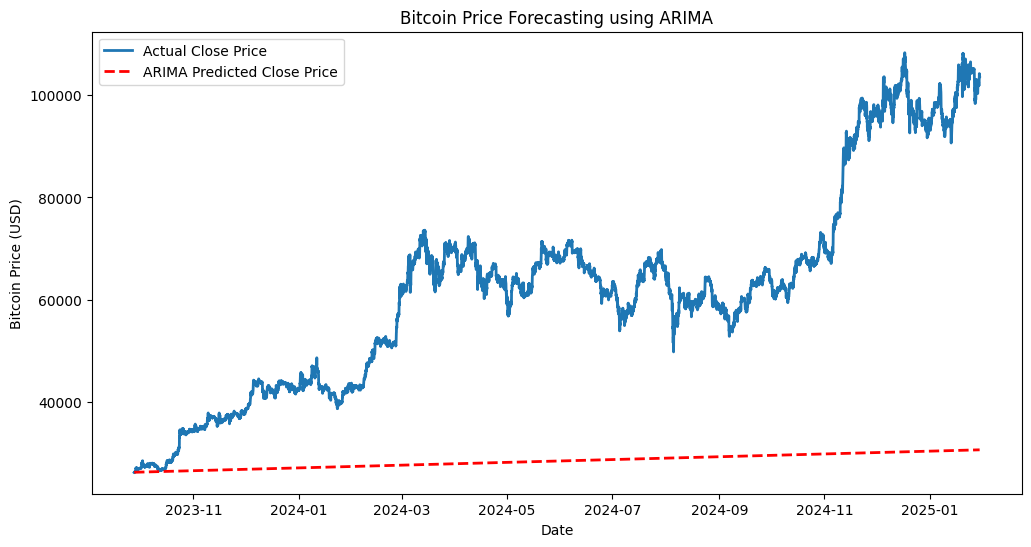

In [5]:
# Apply First Differencing
data['close_diff'] = data['close'].diff()

data.dropna(inplace=True)  # Drop NA values after differencing

# ADF Test for Stationarity
result_diff = adfuller(data['close_diff'])
print(f"ADF Test Statistic: {result_diff[0]}")
print(f"p-value: {result_diff[1]}")

# If data is still non-stationary, consider second differencing
if result_diff[1] > 0.05:
    print("Data is non-stationary. Consider second differencing.")
else:
    print("Data is stationary.")

# Find optimal ARIMA order
stepwise_fit = auto_arima(data['close_diff'], seasonal=False, suppress_warnings=True)
order = stepwise_fit.order
print(f"Optimal ARIMA order: {order}")

# Split data
train_size = int(len(data) * 0.8)  # 80% train, 20% test
arima_train = data.iloc[:train_size]
arima_test = data.iloc[train_size:]

# Train ARIMA model
arima_model = ARIMA(arima_train['close_diff'], order=order)
arima_model = arima_model.fit()
print(arima_model.summary())

# Make predictions
arima_pred = arima_model.predict(start=len(arima_train), end=len(data)-1)

# Evaluate model performance
arima_RMSE = sqrt(mean_squared_error(arima_test['close_diff'], arima_pred))
print(f"ARIMA RMSE: {arima_RMSE}")

# Convert differenced predictions back to actual close prices
last_train_close = arima_train['close'].iloc[-1]
arima_pred_close = last_train_close + arima_pred.cumsum()

# Plot actual vs predicted differenced prices
plt.figure(figsize=(12, 6))
arima_test['close_diff'].plot(label="Actual Differenced Close Price", legend=True, linewidth=2)
arima_pred.plot(label="ARIMA Predictions", linestyle="dashed", legend=True, linewidth=2)
plt.xlabel("Date")
plt.ylabel("Differenced Close Price")
plt.title("ARIMA Model - Differenced Close Price Prediction")
plt.legend()
plt.show()

# Plot actual vs predicted closing prices
plt.figure(figsize=(12, 6))
plt.plot(arima_test.index, arima_test['close'], label="Actual Close Price", linewidth=2)
plt.plot(arima_pred_close.index, arima_pred_close, linestyle="dashed", linewidth=2, color='red', label="ARIMA Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Bitcoin Price Forecasting using ARIMA")
plt.legend()
plt.show()

## Prepare Data for the RNNs

In [6]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [7]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

### Split

In [8]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47061, 15, 5)
y_train shape: (47061,)
X_test shape: (11766, 15, 5)
y_test shape: (11766,)


## Implementing GRU

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15, 30)         │         3,330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30)             │         5,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,941 (34.93 KB)

 Trainable params: 8,941 (34.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0198 - val_loss: 0.0010
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0028 - val_loss: 3.8275e-04
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - val_loss: 4.4673e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - val_loss: 5.3718e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.8851e-04 - val_loss: 0.0013
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.3822e-04 - val_loss: 9.4677e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.2332e-04 - val_loss: 0.0021
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.2724e-04 - val_loss: 0.0011
Epoch 12/5

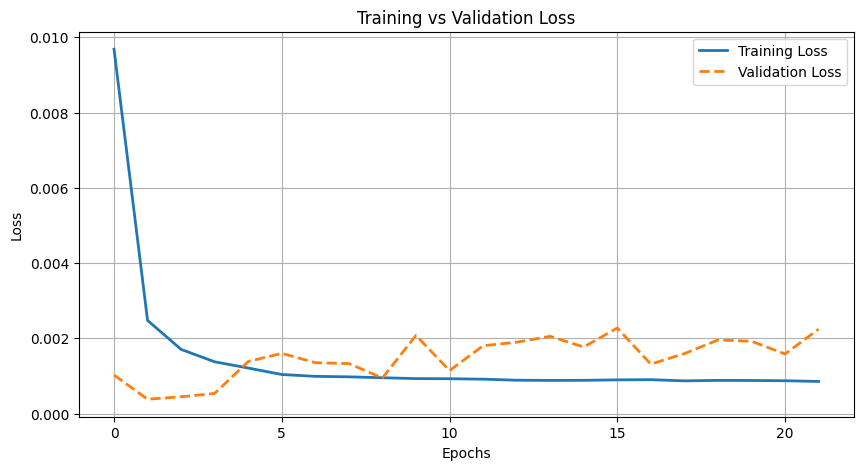

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Mean Absolute Error (MAE): 1548.7964
Mean Squared Error (MSE): 4230768.5535
Root Mean Squared Error (RMSE): 2056.8832
Mean Absolute Percentage Error (MAPE): 2.21%
R-squared (R²): 0.9893


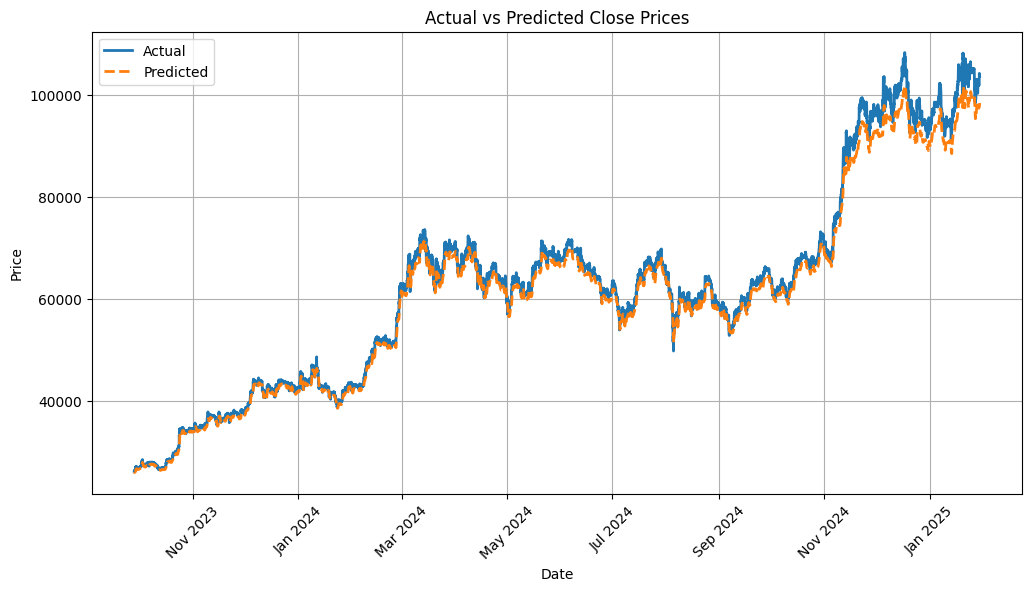

In [9]:
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.5))

# Fourth GRU layer (should NOT return sequences)
gru_model.add(GRU(30, return_sequences=False))  # << FIXED
gru_model.add(Dropout(0.5))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (fix optimizer issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
gru_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
gru_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the GRU model with Early Stopping
history = gru_model.fit(X_train, y_train, 
                        epochs=50,  # Increased epochs
                        batch_size=256, 
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform predictions
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_gru)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Implementing LSTM

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 30)         │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         7,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,671 (45.59 KB)

 Trainable params: 11,671 (45.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0077 - val_loss: 0.0034
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - val_loss: 0.0024
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 9.6154e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0010 - val_loss: 9.0625e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.7859e-04 - val_loss: 4.2890e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.8245e-04 - val_loss: 9.4625e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.8124e-04 - val_loss: 9.0359e-04
Epoch 12/

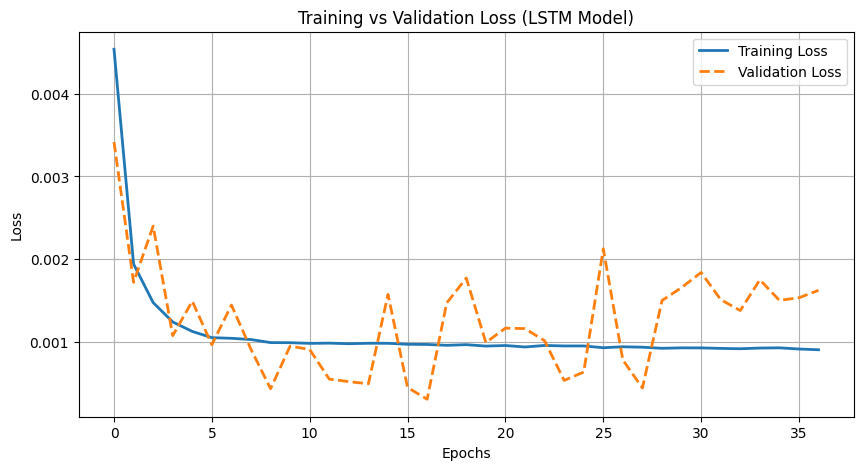

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model Error Statistics:
Mean Absolute Error (MAE): 0.0111
Mean Squared Error (MSE): 0.0003
Root Mean Squared Error (RMSE): 0.0174
Mean Absolute Percentage Error (MAPE): 1.75%
R-squared (R²): 0.9916


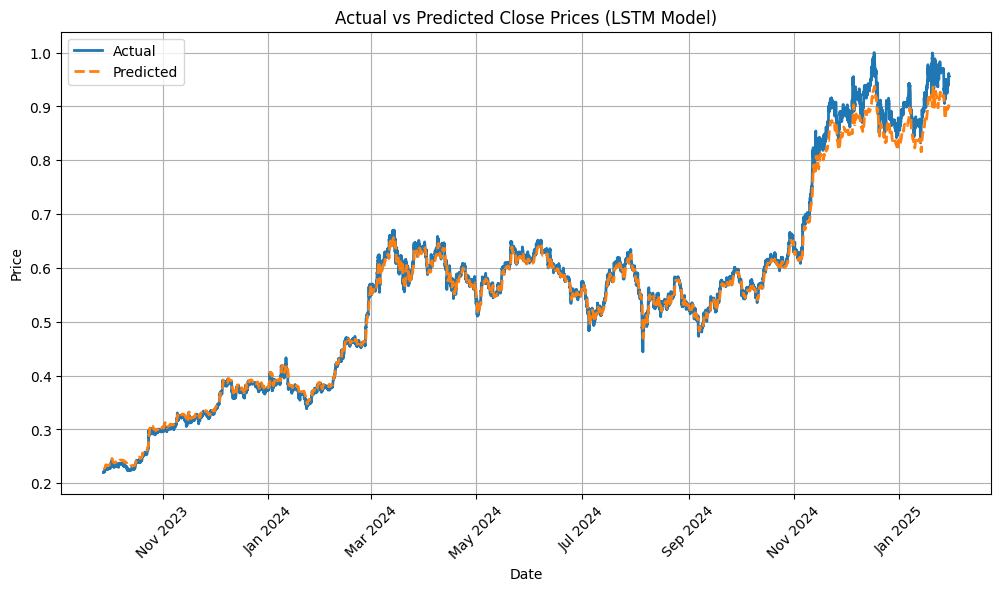

In [10]:
# LSTM Model (Fixed Version)
lstm_model = Sequential()

# First LSTM layer with dropout
lstm_model.add(LSTM(30, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.5))  # Increased dropout for consistency with GRU

# Fourth LSTM layer with dropout (return_sequences=False)
lstm_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2))  # Fixed shape issue
lstm_model.add(Dropout(0.5))

# Output layer
lstm_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model (Fixed Optimizer Issue)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
lstm_model.summary()

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the LSTM model with Early Stopping
history = lstm_model.fit(X_train, y_train, 
                        epochs=50,  # Increased for better learning
                        batch_size=256,  # Increased for smoother validation loss
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (LSTM Model)')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform predictions
predicted_lstm = close_scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_lstm)

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Hybrid LSTM-GRU model

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 15, 32)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,233 (43.88 KB)

 Trainable params: 11,233 (43.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0182 - val_loss: 0.0073
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0036 - val_loss: 0.0046
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0012 - val_loss: 9.0065e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 7.0136e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 12/50
184/184 ━━━━━━━━━━━━━

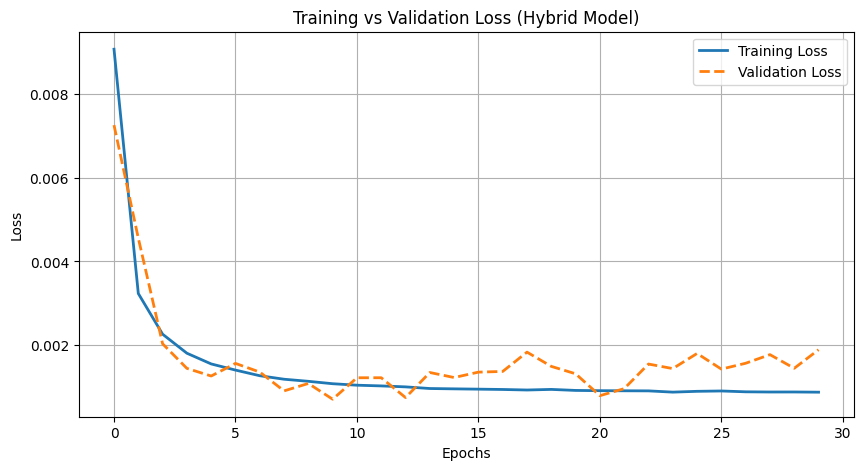

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Hybrid Model Error Statistics:
Mean Absolute Error (MAE): 0.0184
Mean Squared Error (MSE): 0.0007
Root Mean Squared Error (RMSE): 0.0265
Mean Absolute Percentage Error (MAPE): 2.74%
R-squared (R²): 0.9804


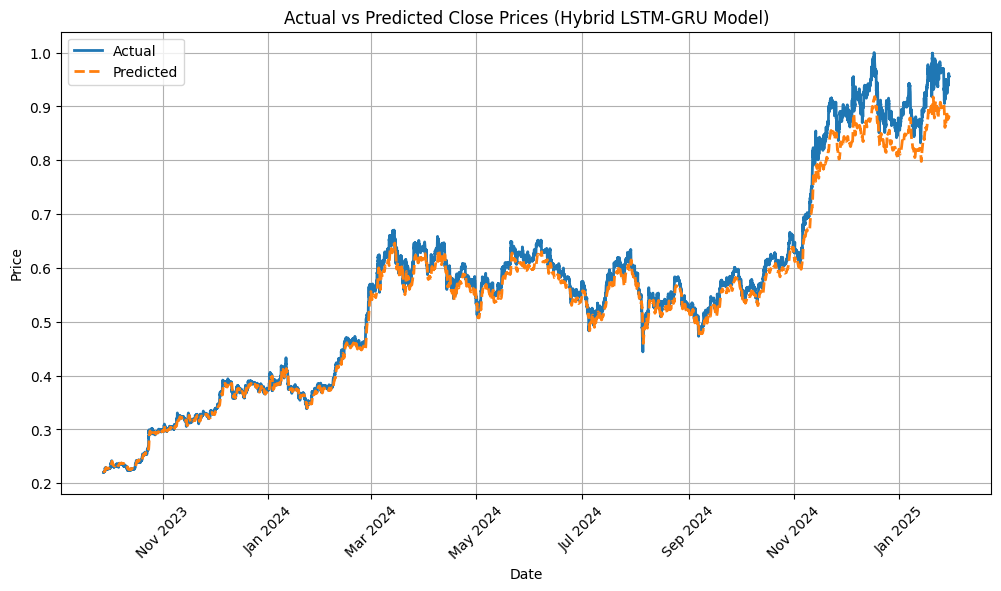

In [11]:
# Hybrid LSTM-GRU Model
hybrid_model = Sequential()

# First LSTM layer with recurrent dropout
hybrid_model.add(LSTM(32, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.5))

# First GRU layer (return_sequences=False to avoid shape issues)
hybrid_model.add(GRU(32, return_sequences=False, recurrent_dropout=0.2))  
hybrid_model.add(Dropout(0.5))

# Output layer
hybrid_model.add(Dense(1))

# Define Learning Rate Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005,  # Start with a small learning rate
    decay_steps=1000,
    decay_rate=0.96,
    staircase=True)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
hybrid_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=50,  
                                  batch_size=256,  # Increased batch size for stability
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid.reshape(-1, 1))  # Fixed reshaping issue
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  
r2 = r2_score(y_test_actual, predicted_hybrid)

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

# Plot Actual vs Predicted Prices
date_index = pd.to_datetime(data.index[-len(y_test_actual):])
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()